# Libraries and Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.metrics import BinaryAccuracy, FalsePositives, TruePositives, FalseNegatives, TrueNegatives, Precision, Recall, AUC
from tensorflow.keras.callbacks import Callback, CSVLogger, EarlyStopping, LearningRateScheduler, ModelCheckpoint

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Hyperparameters for transferred model
CONFIGURATION = {
    'BATCH_SIZE': 16,
    'IM_SIZE': 150,
    'LEARNING_RATE': 0.0001,
    'N_EPOCHS': 25,
    'DROPOUT_RATE': 0.5,
    'REGULARIZATION_RATE': 0.3,
    'N_DENSE_1': 128,
    'N_DENSE_2': 1,
    'CLASS_NAMES': ['clean', 'dirty']
    }



In [ ]:
# Hyperparameters for custom model
CONFIGURATION = {
    'BATCH_SIZE': 16,
    'IM_SIZE': 150,
    'LEARNING_RATE': 0.0001,
    'N_EPOCHS': 40,
    'DROPOUT_RATE': 0.5,
    'REGULARIZATION_RATE': 0.0001,
    'N_FILTERS': 128,
    'KERNEL_SIZE': 3,
    'N_STRIDES': 1,
    'POOL_SIZE': 2,
    'N_DENSE_1': 256,
    'N_DENSE_2': 128,
    'N_DENSE_3': 1,
    'CLASS_NAMES': ['clean', 'dirty']
    }

# Data Preparation

## Unzip the File and Extract Data

Access the `CleanDirtClassification.zip` file from the specified directory and extract it into the `UnzippedCleanDirtclass` folder.

In [ ]:
# source_path = '/content/drive/MyDrive/new'
# os.chdir(source_path)

# dest_path = os.path.join(source_path,'UnzippedCleanDirtclass')
# !unzip 'CleanDirtClassification.zip' -d   dest_path #'/content/drive/MyDrive/new/UnzippedCleanDirtclass'

## Create Temporary Directories

Create temporary directories for organizing images into train, validation, and test sets with class-based subdirectories.

In [ ]:
base_dir  = '/content/new'
os.mkdir(base_dir)


In [ ]:
# train/valid/test_dir

train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)

valid_dir = os.path.join(base_dir, 'valid')
os.mkdir(valid_dir)

test_dir = os.path.join(base_dir, 'test')
os.mkdir(test_dir)


In [ ]:
# train/valid/test_clean_dir

train_clean_dir = os.path.join(train_dir, 'clean')
os.mkdir(train_clean_dir)

valid_clean_dir = os.path.join(valid_dir, 'clean')
os.mkdir(valid_clean_dir)

test_clean_dir = os.path.join(test_dir, 'clean')
os.mkdir(test_clean_dir)

In [ ]:
# train/valid/test_dirty_dir

train_dirty_dir = os.path.join(train_dir, 'dirty')
os.mkdir(train_dirty_dir)

valid_dirty_dir = os.path.join(valid_dir, 'dirty')
os.mkdir(valid_dirty_dir)

test_dirty_dir = os.path.join(test_dir, 'dirty')
os.mkdir(test_dirty_dir)

## Structure Files based on Classes

The dataset contains images from two classes in one folder.
A CSV file with image names and their class labels is used to separate them into their respective categories.

In [ ]:
# Labels from csv_file -> spliting two classes and storing in different directories

df = pd.read_csv('/content/drive/MyDrive/new/UnzippedCleanDirtclass/metadata.csv') # CSV file

image_source  = '/content/drive/MyDrive/new/UnzippedCleanDirtclass/Images/Images'  # Path to images


clean_images = os.path.join(base_dir, 'clean')
os.mkdir(clean_images)
dirty_images = os.path.join(base_dir, 'dirty')
os.mkdir(dirty_images)

for index, row in df.iterrows():
    if row['label'] == 0:
        src = os.path.join(image_source, row['filename'] )
        dst = os.path.join(clean_images, row['filename'])
        shutil.copyfile(src, dst)


    elif row['label'] == 1:
        src = os.path.join(image_source,row['filename'] )
        dst = os.path.join(dirty_images , row['filename'])
        shutil.copyfile(src, dst)





## Transfer Images to Directories

Distribute images from the structured folder into temporary directories for train, validation, and test splits.


In [ ]:
# Clean
# Clean_images -> train_test_split
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

clean = sorted([
    file for file in os.listdir(clean_images)
    if file.lower().endswith(valid_extensions)
])
train_clean , other_clean_data = train_test_split(clean, test_size = 0.25, random_state = 42)
val_clean, test_clean = train_test_split(other_clean_data, test_size = 0.5, random_state = 42)


for file_name in train_clean:
    src = os.path.join(clean_images, file_name)
    dst = os.path.join(train_clean_dir, file_name)

    shutil.copyfile(src, dst)

for file_name in val_clean:
    src = os.path.join(clean_images, file_name)
    dst = os.path.join(valid_clean_dir, file_name)

    shutil.copyfile(src, dst)


for file_name in test_clean:
    src = os.path.join(clean_images, file_name)
    dst = os.path.join(test_clean_dir, file_name)

    shutil.copyfile(src, dst)



In [ ]:
# Dirty
# Dirty_images -> train_test_split

dirty = sorted([file for file in os.listdir(dirty_images) if os.path.isfile(os.path.join(dirty_images, file))])

train_dirty, other_dirty_data = train_test_split(dirty, test_size = 0.25, random_state = 42)
val_dirty, test_dirty = train_test_split(other_dirty_data, test_size = 0.5, random_state = 42)



for file_name in train_dirty:
    src = os.path.join(dirty_images, file_name)
    dst = os.path.join(train_dirty_dir, file_name)

    shutil.copyfile(src, dst)

for file_name in val_dirty :
    src = os.path.join(dirty_images, file_name)
    dst = os.path.join(valid_dirty_dir, file_name)

    shutil.copyfile(src, dst)


for file_name in test_dirty:
    src = os.path.join(dirty_images, file_name)
    dst = os.path.join(test_dirty_dir, file_name)

    shutil.copyfile(src, dst)


In [ ]:
print(len(os.listdir('/content/new/train/dirty')))
print(len(os.listdir('/content/new/train/clean')))


print(len(os.listdir('/content/new/test/dirty')))
print(len(os.listdir('/content/new/test/clean')))


print(len(os.listdir('/content/new/valid/clean')))
print(len(os.listdir('/content/new/valid/dirty')))

93
84
16
15
14
15


# TensorFlow Dataset Preparation



In [ ]:
trainDataGen = ImageDataGenerator(rescale = 1./255)
testDataGen = ImageDataGenerator(rescale = 1./255)


train_dataset = trainDataGen.flow_from_directory(
    train_dir,
    target_size = (CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    batch_size = CONFIGURATION['BATCH_SIZE'],
    class_mode = 'binary',
    shuffle = True,
    # seed = SEED
)

valid_dataset = testDataGen.flow_from_directory(
    valid_dir,
    batch_size =  CONFIGURATION['BATCH_SIZE'],
    target_size = (CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    class_mode = 'binary',
    shuffle = False,
    # seed = SEED

)


test_dataset = testDataGen.flow_from_directory(
    test_dir,
    target_size = (CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    batch_size = CONFIGURATION['BATCH_SIZE'],
    class_mode = 'binary',
    shuffle = False,
    # seed = SEED


)



Found 177 images belonging to 2 classes.
Found 29 images belonging to 2 classes.
Found 31 images belonging to 2 classes.


In [ ]:

for train_images, train_labels in train_dataset:
    print('train image shape:' , train_images.shape,'train label shape: ', train_labels.shape)
    print('train label:', train_labels)
    print('train image:', train_images)
    break



train image shape: (16, 150, 150, 3) train label shape:  (16,)
train label: [0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 1.]
train image: [[[[0.29411766 0.4784314  0.75294125]
   [0.29803923 0.48235297 0.7568628 ]
   [0.3019608  0.48627454 0.7607844 ]
   ...
   [0.3019608  0.454902   0.6862745 ]
   [0.3019608  0.454902   0.6862745 ]
   [0.29803923 0.45098042 0.68235296]]

  [[0.29411766 0.4784314  0.75294125]
   [0.3019608  0.48627454 0.7607844 ]
   [0.30980393 0.49411768 0.7686275 ]
   ...
   [0.30980393 0.46274513 0.69411767]
   [0.3137255  0.4666667  0.69803923]
   [0.30588236 0.45882356 0.6901961 ]]

  [[0.30588236 0.4901961  0.76470596]
   [0.30588236 0.4901961  0.76470596]
   [0.3137255  0.49803925 0.7725491 ]
   ...
   [0.3137255  0.4666667  0.69803923]
   [0.30980393 0.46274513 0.69411767]
   [0.30588236 0.45882356 0.6901961 ]]

  ...

  [[0.6862745  0.654902   0.5803922 ]
   [0.7019608  0.67058825 0.59607846]
   [0.6862745  0.654902   0.5803922 ]
   ...
   [0.5058824  0.47058

In [ ]:
images, labels = next(test_dataset)  # Choose one batch of the dataset
print('batch images shape: ',images.shape)
print('batch labels shape: ', labels.shape)

# If batch_size = 10:
# test -> 31 -> 10, 10, 10, 1
# val -> 29 -> 10, 10, 9
# train -> 177 -> 10(10) -> 7(10) -> 7


batch images shape:  (16, 150, 150, 3)
batch labels shape:  (16,)


## Visualize Images with Labels

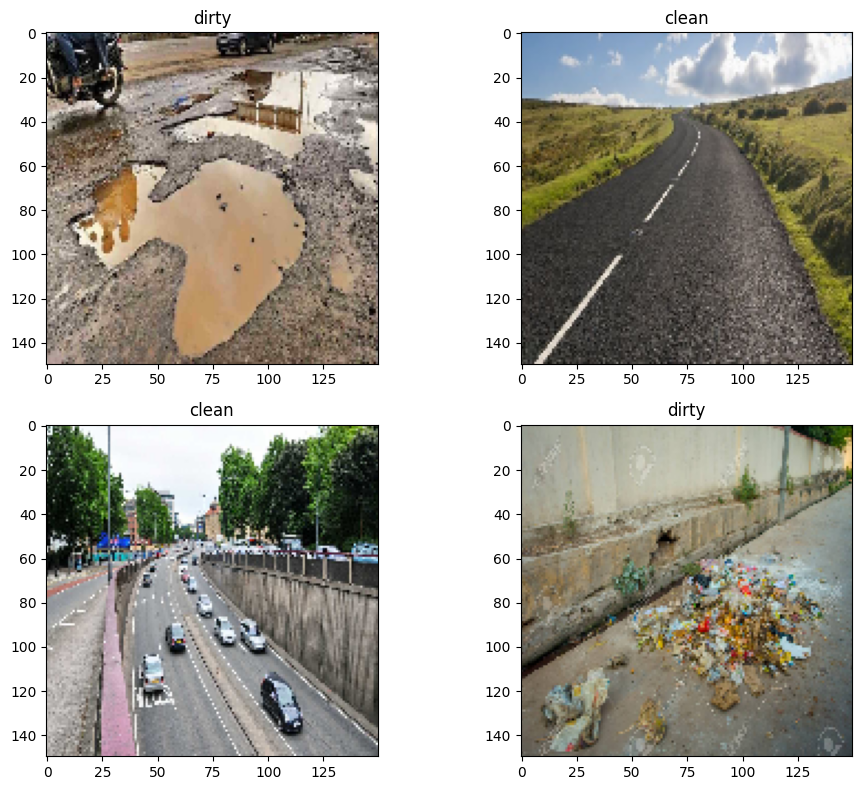

In [ ]:
images, labels = next(train_dataset)  ## test_dataset or train_dataset

class_labels = list(train_dataset.class_indices.keys())

plt.figure(figsize=(10, 8))
for i in range(0,4):
    plt.subplot(2,2, i+ 1 )
    plt.imshow(images[i])
    plt.title(class_labels[int(labels[i])])
plt.tight_layout()


# Create the Model


## Transferred model

In [ ]:

# Transfer learning
base_model = tf.keras.applications.MobileNetV2(input_shape=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE'], 3),
                                               include_top=False,
                                               weights="imagenet")

base_model.trainable = False  # freeze base model

transferred_model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(CONFIGURATION['N_DENSE_1'], activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(CONFIGURATION['DROPOUT_RATE']),
    tf.keras.layers.Dense(CONFIGURATION['N_DENSE_2'], activation="sigmoid")  # binary classification

])


/tmp/ipykernel_576/647678668.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE'], 3),


In [ ]:
transferred_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

## Custom model

In [ ]:

tf.keras.utils.set_random_seed(42)
custom_model = tf.keras.models.Sequential([

        tf.keras.layers.InputLayer(shape = (CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE'], 3)),
        tf.keras.layers.Conv2D(filters = CONFIGURATION['N_FILTERS'],
                               kernel_size =(CONFIGURATION['KERNEL_SIZE'], CONFIGURATION['KERNEL_SIZE']),
                               strides = CONFIGURATION['N_STRIDES'],
                               padding = 'same',
                               kernel_regularizer=tf.keras.regularizers.l2(CONFIGURATION['REGULARIZATION_RATE'])),
        tf.keras.layers.Activation('relu')  ,
        tf.keras.layers.MaxPool2D((CONFIGURATION['POOL_SIZE'],CONFIGURATION['POOL_SIZE'])),
        tf.keras.layers.Dropout(CONFIGURATION['DROPOUT_RATE']/2),


        tf.keras.layers.Conv2D(filters =int(CONFIGURATION['N_FILTERS']/2),
                               kernel_size = (CONFIGURATION['KERNEL_SIZE'],CONFIGURATION['KERNEL_SIZE']),
                               strides = CONFIGURATION['N_STRIDES'],
                               padding = 'same',
                               kernel_regularizer=tf.keras.regularizers.l2(CONFIGURATION['REGULARIZATION_RATE'])),
        tf.keras.layers.Activation('relu')  ,
        tf.keras.layers.MaxPool2D((CONFIGURATION['POOL_SIZE'],CONFIGURATION['POOL_SIZE'])),
        tf.keras.layers.Dropout(CONFIGURATION['DROPOUT_RATE']/2),


        tf.keras.layers.Conv2D(filters =int(CONFIGURATION['N_FILTERS']/4),
                               kernel_size = (CONFIGURATION['KERNEL_SIZE'],CONFIGURATION['KERNEL_SIZE']),
                               strides = CONFIGURATION['N_STRIDES'],
                               padding = 'same',
                               kernel_regularizer=tf.keras.regularizers.l2(CONFIGURATION['REGULARIZATION_RATE'])),
        tf.keras.layers.Activation('relu')  ,
        tf.keras.layers.MaxPool2D((CONFIGURATION['POOL_SIZE'],CONFIGURATION['POOL_SIZE'])),
        tf.keras.layers.Dropout(CONFIGURATION['DROPOUT_RATE']/2),


        tf.keras.layers.Flatten(),


        tf.keras.layers.Dense(CONFIGURATION['N_DENSE_1'], activation='relu'),
        tf.keras.layers.Dropout(CONFIGURATION['DROPOUT_RATE']),
        tf.keras.layers.Dense(CONFIGURATION['N_DENSE_2'], activation= 'relu', kernel_regularizer=tf.keras.regularizers.l2(CONFIGURATION['REGULARIZATION_RATE'])),
        tf.keras.layers.Dropout(CONFIGURATION['DROPOUT_RATE']),
        tf.keras.layers.Dense(CONFIGURATION['N_DENSE_3'], activation='sigmoid')
  ]

)


In [ ]:
custom_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 37, 37, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 18, 18, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       518,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,249 (2.08 MB)

 Trainable params: 544,825 (2.08 MB)

 Non-trainable params: 424 (1.66 KB)

# Metrics

In [ ]:
metrics = [BinaryAccuracy(name = 'accuracy'), FalsePositives(name = 'fp'), FalseNegatives(name  = 'fn'), TruePositives(name = 'tp'),
           TrueNegatives(name = 'tn'), Precision(name = 'precision'), Recall(name = 'recall'), AUC(name = 'auc')]


# Callbacks

##CheckPoint

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1)

## EarlyStopping

In [ ]:
es_callback = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', min_delta = 0, patience = 3,verbose = 1,mode ='auto', baseline = None )



# Model Training

In [ ]:
# Compile the model
transferred_model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate = CONFIGURATION['LEARNING_RATE']),
              metrics = metrics)


In [ ]:
# Train the model
tf.random.set_seed(42)
history = transferred_model.fit(train_dataset,
          epochs = CONFIGURATION['N_EPOCHS'],
          validation_data = valid_dataset,
          callbacks = [es_callback, checkpoint]
          )


Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6689 - auc: 0.7158 - fn: 13.9167 - fp: 16.0833 - loss: 0.7123 - precision: 0.6718 - recall: 0.6803 - tn: 30.5833 - tp: 32.1667
Epoch 1: val_loss improved from None to 0.46527, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.6780 - auc: 0.7400 - fn: 27.0000 - fp: 30.0000 - loss: 0.6637 - precision: 0.6875 - recall: 0.7097 - tn: 54.0000 - tp: 66.0000 - val_accuracy: 0.7586 - val_auc: 0.9667 - val_fn: 0.0000e+00 - val_fp: 7.0000 - val_loss: 0.4653 - val_precision: 0.6818 - val_recall: 1.0000 - val_tn: 7.0000 - val_tp: 15.0000
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8800 - auc: 0.9113 - fn: 9.0000 - fp: 2.9167 - loss: 0.3736 - precision: 0.9324 - recall: 0.8375 - tn: 41.5000 - tp: 41.8333
Epoch 2: val_loss improved from 0.46527 to 0.32188, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.8701 - auc: 0.9241 - fn: 18.0000 - fp: 5.0000 - loss: 0.3546 - precision: 0.9375 - recall: 0.8065 - tn: 79.0000 - tp: 75.0000 - val_accuracy: 0.8276 - val_auc: 0.9833 - val_fn: 0.0000e+00 - val_fp: 5.0000 - val_loss: 0.3219 - val_precision: 0.7500 - val_recall: 1.0000 - val_tn: 9.0000 - val_tp: 15.0000
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8885 - auc: 0.9550 - fn: 4.4167 - fp: 6.2500 - loss: 0.2827 - precision: 0.8412 - recall: 0.9158 - tn: 44.9167 - tp: 40.9167
Epoch 3: val_loss improved from 0.32188 to 0.23057, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.8983 - auc: 0.9615 - fn: 10.0000 - fp: 8.0000 - loss: 0.2560 - precision: 0.9121 - recall: 0.8925 - tn: 76.0000 - tp: 83.0000 - val_accuracy: 0.9310 - val_auc: 0.9952 - val_fn: 0.0000e+00 - val_fp: 2.0000 - val_loss: 0.2306 - val_precision: 0.8824 - val_recall: 1.0000 - val_tn: 12.0000 - val_tp: 15.0000
Epoch 4/25
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8954 - auc: 0.9680 - fn: 8.3636 - fp: 1.7273 - loss: 0.2425 - precision: 0.9525 - recall: 0.8382 - tn: 45.0000 - tp: 40.9091
Epoch 4: val_loss improved from 0.23057 to 0.17976, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.8870 - auc: 0.9658 - fn: 16.0000 - fp: 4.0000 - loss: 0.2496 - precision: 0.9506 - recall: 0.8280 - tn: 80.0000 - tp: 77.0000 - val_accuracy: 0.9310 - val_auc: 0.9952 - val_fn: 0.0000e+00 - val_fp: 2.0000 - val_loss: 0.1798 - val_precision: 0.8824 - val_recall: 1.0000 - val_tn: 12.0000 - val_tp: 15.0000
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9396 - auc: 0.9924 - fn: 4.6667 - fp: 1.5000 - loss: 0.1476 - precision: 0.9778 - recall: 0.9037 - tn: 43.4167 - tp: 43.1667
Epoch 5: val_loss improved from 0.17976 to 0.14610, saving model to best_model.h5


...


Epoch 21: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.9774 - auc: 0.9968 - fn: 0.0000e+00 - fp: 4.0000 - loss: 0.0751 - precision: 0.9588 - recall: 1.0000 - tn: 80.0000 - tp: 93.0000 - val_accuracy: 0.9655 - val_auc: 1.0000 - val_fn: 1.0000 - val_fp: 0.0000e+00 - val_loss: 0.0551 - val_precision: 1.0000 - val_recall: 0.9333 - val_tn: 14.0000 - val_tp: 14.0000
Epoch 22/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9849 - auc: 1.0000 - fn: 0.0000e+00 - fp: 1.5000 - loss: 0.0402 - precision: 0.9739 - recall: 1.0000 - tn: 39.4167 - tp: 50.5833
Epoch 22: val_loss improved from 0.05508 to 0.05210, saving model to best_model.h5



Epoch 22: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.9831 - auc: 1.0000 - fn: 0.0000e+00 - fp: 3.0000 - loss: 0.0417 - precision: 0.9688 - recall: 1.0000 - tn: 81.0000 - tp: 93.0000 - val_accuracy: 0.9655 - val_auc: 1.0000 - val_fn: 1.0000 - val_fp: 0.0000e+00 - val_loss: 0.0521 - val_precision: 1.0000 - val_recall: 0.9333 - val_tn: 14.0000 - val_tp: 14.0000
Epoch 23/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9922 - auc: 1.0000 - fn: 0.0000e+00 - fp: 0.7500 - loss: 0.0268 - precision: 0.9852 - recall: 1.0000 - tn: 43.8333 - tp: 48.1667
Epoch 23: val_loss improved from 0.05210 to 0.05024, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 308ms/step - accuracy: 0.9944 - auc: 1.0000 - fn: 0.0000e+00 - fp: 1.0000 - loss: 0.0295 - precision: 0.9894 - recall: 1.0000 - tn: 83.0000 - tp: 93.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.0502 - val_precision: 1.0000 - val_recall: 1.0000 - val_tn: 14.0000 - val_tp: 15.0000
Epoch 24/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9971 - auc: 0.9996 - fn: 0.0000e+00 - fp: 0.5000 - loss: 0.0766 - precision: 0.9948 - recall: 1.0000 - tn: 44.8333 - tp: 56.1667    
Epoch 24: val_loss improved from 0.05024 to 0.04721, saving model to best_model.h5



Epoch 24: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.9718 - auc: 0.9958 - fn: 0.0000e+00 - fp: 5.0000 - loss: 0.0911 - precision: 0.9490 - recall: 1.0000 - tn: 79.0000 - tp: 93.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.0472 - val_precision: 1.0000 - val_recall: 1.0000 - val_tn: 14.0000 - val_tp: 15.0000
Epoch 25/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9010 - auc: 0.9166 - fn: 0.0833 - fp: 1.0000 - loss: 0.0981 - precision: 0.8829 - recall: 0.9158 - tn: 44.3333 - tp: 43.5833    
Epoch 25: val_loss improved from 0.04721 to 0.04578, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.9887 - auc: 0.9995 - fn: 1.0000 - fp: 1.0000 - loss: 0.0485 - precision: 0.9892 - recall: 0.9892 - tn: 83.0000 - tp: 92.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.0458 - val_precision: 1.0000 - val_recall: 1.0000 - val_tn: 14.0000 - val_tp: 15.0000


 # Loss and Accuracy Visualization

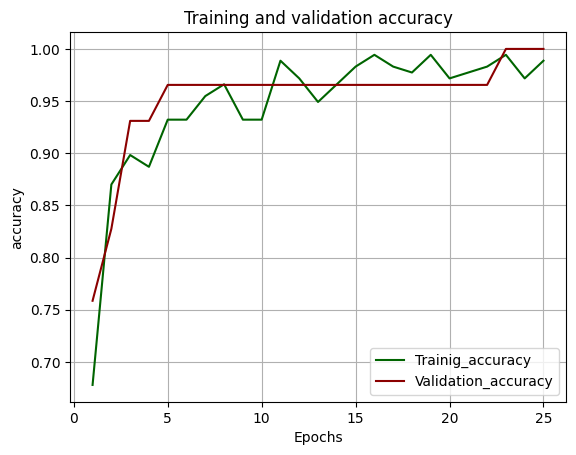

In [ ]:
loss = history.history['accuracy']
val_loss = history.history['val_accuracy']
epochs = range(1, len(loss)+ 1)
plt.plot(epochs, loss, 'darkgreen', label = 'Trainig_accuracy'),
plt.plot(epochs, val_loss, 'darkred', label = 'Validation_accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.grid()


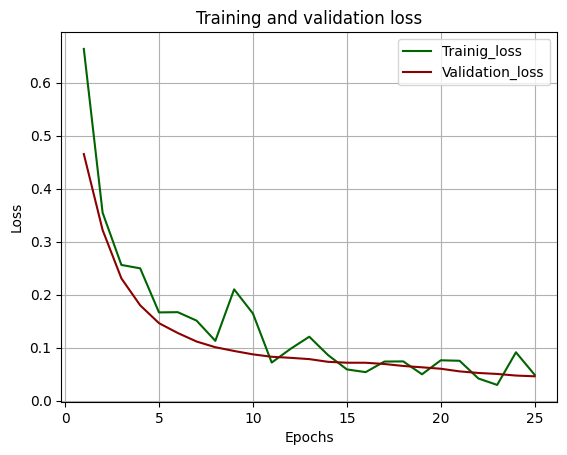

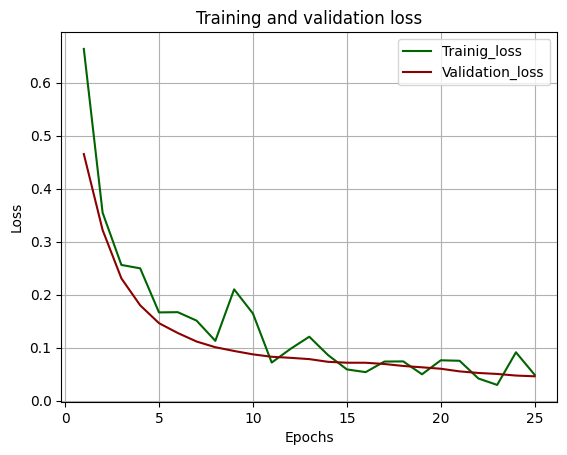

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss)+ 1)
plt.plot(epochs, loss, 'darkgreen', label = 'Trainig_loss'),
plt.plot(epochs, val_loss, 'darkred', label = 'Validation_loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Model Prediction

## Image and Label Visualization

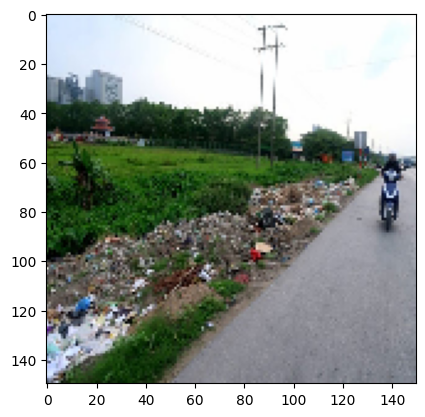

In [ ]:
images, labels = next(iter(test_dataset))
images.shape
plt.imshow(images[0])
# with each run it will show first image of each batch (it is possible that index is out of the range because the number of images in a batch can change)


(16, 150, 150, 3)
(16,)


Text(0.5, 1.0, 'clean')

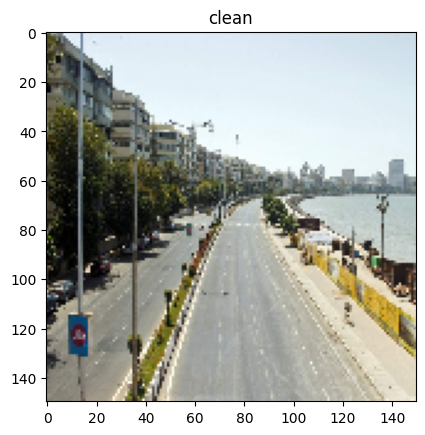

In [ ]:
# images, labels = next(iter(test_dataset))  # all of this in the first run have one batch an other runs 10.
# print(images.shape)
# print(labels.shape)

# images, labels = iter(next(test_dataset))
# print(images.shape)
# print(labels.shape)

images, labels = next(test_dataset)
print(images.shape)
print(labels.shape)


class_labels = list(test_dataset.class_indices.keys())
# print(class_labels)

#  Plot one sample with its label
sample_0 = images[0], labels[0]
# plt.imshow(images[0])
plt.imshow(sample_0[0])
# plt.title(class_labels[int(labels[0])])
plt.title(class_labels[int(sample_0[1])])


## Visualize the Model Prediction

### Prediction for one single image

first_image_of_the_Batch_shape: (150, 150, 3)
first_label_of_the_Batch_shape: ()
batch_image_shape: (15, 150, 150, 3)
batch_label_shape: (15,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
model_prediction: [[0.8872085]] and sample_label: 1
Pred -> Label [[ True]]


/tmp/ipykernel_576/4012252204.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f'{class_labels[int(sample_label)]}:{class_labels[int(pred_sample>0.5)]}')


Text(0.5, 1.0, 'dirty:dirty')

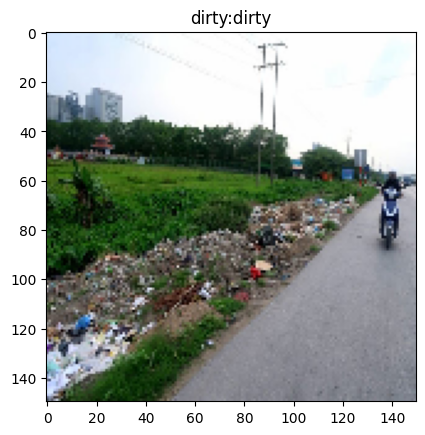

In [ ]:

images, labels = next(test_dataset)
sample_img = images[0]
sample_label = labels[0]   #-> float; shape=()


print('first_image_of_the_Batch_shape:', images[4].shape) # -> (150, 150, 3)
print('first_label_of_the_Batch_shape:', labels[4].shape) # -> ()

print('batch_image_shape:', images.shape) # -> (10, 150, 150, 3)
print('batch_label_shape:', labels.shape) # -> (10,)


# Prediction for one sample by model ->  (150, 150, 3) ->  (1, 150, 150, 3)
pred_sample = transferred_model.predict(sample_img[np.newaxis, ...]) # ->  0.15 but label is 0, 1

print('model_prediction:', pred_sample, 'and sample_label:' ,int(sample_label))
print('Pred -> Label', (pred_sample>0.5) == int(sample_label))


plt.imshow(sample_img)
plt.title(f'{class_labels[int(sample_label)]}:{class_labels[int(pred_sample>0.5)]}')


### Prediction for a batch of images

In [ ]:

## The number of examples in the last batch will be different than others.

images, labels = next(test_dataset)

preds = transferred_model.predict(images)

print('Labels_shape:', labels.shape)
print('Preds_shape:', preds.shape)

print('Labels:', labels)
print('Raw predictions:', preds)


preds = preds.flatten()
labels == (preds > 0.5)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Labels_shape: (16,)
Preds_shape: (16, 1)
Labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Raw predictions: [[5.5765025e-03]
 [4.3406284e-01]
 [5.7443750e-01]
 [1.1569714e-02]
 [4.2215032e-03]
 [2.6553809e-03]
 [1.0430829e-03]
 [6.1449216e-04]
 [8.1386484e-02]
 [2.4579184e-03]
 [8.9277430e-03]
 [6.4751875e-01]
 [1.9078940e-02]
 [5.2656963e-02]
 [2.1291034e-01]
 [9.9988377e-01]]


array([ True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True])

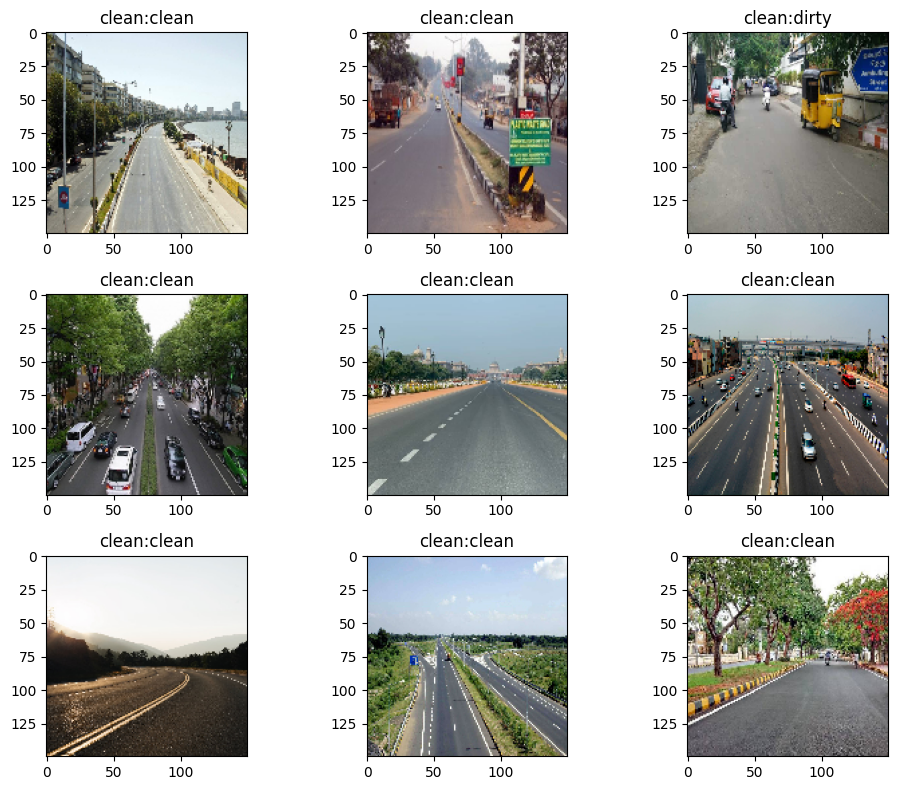

In [ ]:
# Visualize the predictions of a model for a batch of images

preds = (preds > 0.5).astype("int32")

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (10, 8))
axes = axes.flatten()
for img, ax, label, pred in zip(images, axes, labels, preds):
   ax.imshow(img)
   ax.set_title(f'{class_labels[int(label)]}:{class_labels[int(pred)]}')
plt.tight_layout()

### Prediction for testset

In [ ]:
# Prediction for all batches in the test_set by the model

# len(test_dataset) gives the number of batches needed to cover all samples once
raw_predictions = transferred_model.predict(test_dataset, steps=len(test_dataset))

# Convert raw predictions to binary predictions based on a threshold (e.g., 0.5)
preds = (raw_predictions > 0.5).astype("int32").flatten()

# Get the true labels directly from the test_dataset (ImageDataGenerator)
# Since shuffle=False was used when creating test_dataset, test_dataset.classes
# will return labels in the same order as the images are yielded.
labels = test_dataset.classes

print(f"Collected predictions shape: {preds.shape}")
print(f"Collected labels shape: {labels.shape}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 17s/step
Collected predictions shape: (31,)
Collected labels shape: (31,)


# Model Evaluation

## Confusion Matrix

[[13  2]
 [ 0 16]]


Text(95.72222222222221, 0.5, 'Actual')

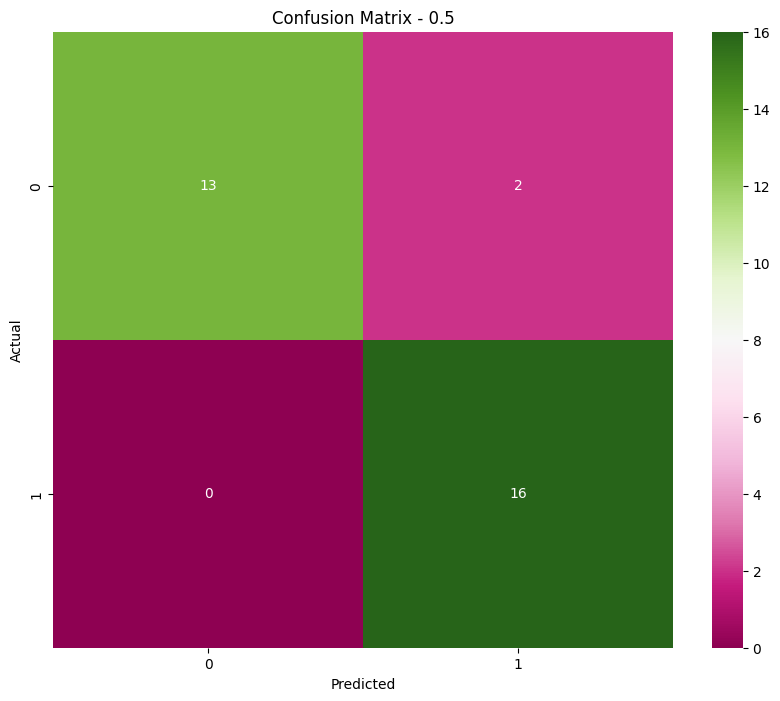

In [ ]:
threshold = 0.5
cm = confusion_matrix(labels, preds)
print(cm )

plt.figure(figsize = (10,8))
sns.heatmap(cm,
            annot = True,
            cmap = 'PiYG' )
plt.title('Confusion Matrix - {}'.format(threshold))
plt.xlabel('Predicted')
plt.ylabel('Actual')

## ROC Plot

Length of False Positive Rates: 4
Length of True Positive Rates: 4


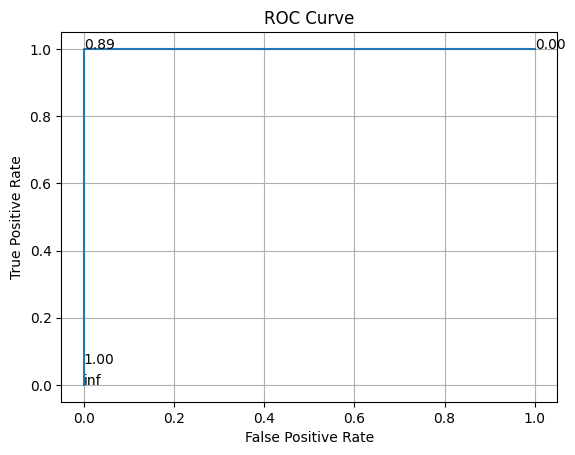

In [ ]:

# For ROC curve, we need the raw prediction probabilities, not the binary predictions
fp, tp, thresholds = roc_curve(labels, raw_predictions.flatten())

print(f"Length of False Positive Rates: {len(fp)}")
print(f"Length of True Positive Rates: {len(tp)}")

plt.plot(fp, tp)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid()


skip = max(1, len(thresholds) // 10) # Adjust skip dynamically
for i in range(0, len(thresholds), skip):
    plt.text(fp[i], tp[i], f'{thresholds[i]:.2f}')

# Data Augmentation


## Load Dataset

In [ ]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/new/train',
    image_size = (CONFIGURATION['IM_SIZE'],CONFIGURATION['IM_SIZE']),
    batch_size  = CONFIGURATION['BATCH_SIZE'],
    labels="inferred",
    label_mode="int"
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/new/valid' ,
    image_size = (CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    batch_size  = CONFIGURATION['BATCH_SIZE'],
    shuffle = False,
    labels="inferred",
    label_mode="int",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/new/test' ,
    image_size = (CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    batch_size  = CONFIGURATION['BATCH_SIZE'],
    labels="inferred",
    label_mode="int",
    shuffle = False
)


Found 177 files belonging to 2 classes.
Found 29 files belonging to 2 classes.
Found 31 files belonging to 2 classes.


## Augmentation Function

In [ ]:
def resize_rescale(image,label):
   image = tf.image.resize(image,(150,150))/255.0
   return image, label

def augmentation(image, label):
    image, label = resize_rescale(image, label)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.05)
    return image, label



## Build the Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(augmentation, num_parallel_calls=AUTOTUNE).prefetch(tf.data.AUTOTUNE)
valid_ds = valid_ds.map(resize_rescale,  num_parallel_calls=AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(resize_rescale,  num_parallel_calls=AUTOTUNE).prefetch(tf.data.AUTOTUNE)



## Visualize the augmented images

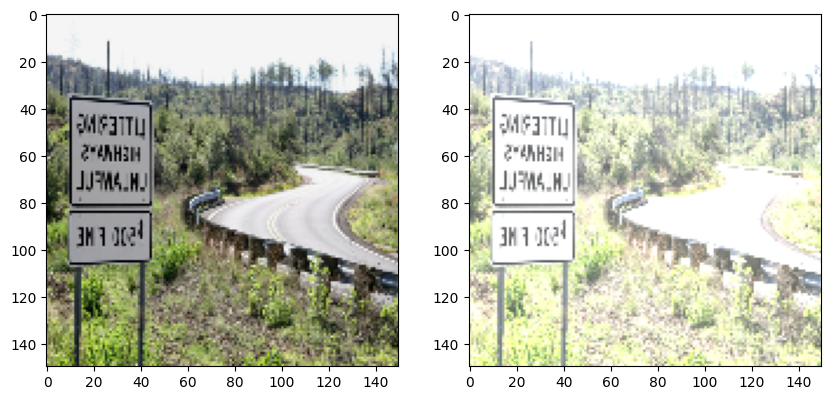

In [ ]:
# Visualize the Augmentation  options


def VisualizeImg(original,  augmented):
    fig, axe = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 8))
    axe = axe.flatten()
    for i, ax in zip([original, augmented ], axe):
        ax.imshow(i )
original , label  = next(iter(train_ds))
original.shape
original = original[0]
# original[0].shape
augmented = tf.image.adjust_brightness(original, delta = 0.4) # add brightness with adding to the value of the pixels

VisualizeImg(original, augmented)

In [ ]:
import os
from PIL import Image

root = "/content/new/valid"

for root_dir, _, files in os.walk(root):
    for file in files:
        path = os.path.join(root_dir, file)
        try:
            img = Image.open(path)
            img.verify()  # verify image integrity
        except Exception as e:
            print("Broken file:", path)

In [ ]:
# tf.image --> find from Documentation


## Train the Model

In [ ]:

transferred_model.compile(loss= tf.keras.losses.BinaryCrossentropy(),
                               optimizer = tf.keras.optimizers.Adam(learning_rate = CONFIGURATION['LEARNING_RATE']),
                               metrics = metrics
                               )

history = transferred_model.fit(train_ds,
                                epochs = CONFIGURATION['N_EPOCHS'],
                                validation_data = valid_ds,
                                callbacks = [checkpoint],
                                verbose = 1 )

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7461 - auc: 0.8335 - fn: 18.8333 - fp: 17.6667 - loss: 0.6929 - precision: 0.7578 - recall: 0.7409 - tn: 46.6667 - tp: 48.5833
Epoch 1: val_loss did not improve from 0.04578
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7039 - auc: 0.7970 - fn: 32.0000 - fp: 29.0000 - loss: 0.6698 - precision: 0.7238 - recall: 0.7037 - tn: 69.0000 - tp: 76.0000 - val_accuracy: 0.8276 - val_auc: 0.9714 - val_fn: 0.0000e+00 - val_fp: 5.0000 - val_loss: 0.3944 - val_precision: 0.7500 - val_recall: 1.0000 - val_tn: 9.0000 - val_tp: 15.0000
Epoch 2/25
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8176 - auc: 0.9053 - fn: 8.0909 - fp: 8.8182 - loss: 0.4067 - precision: 0.7847 - recall: 0.8448 - tn: 40.2727 - tp: 38.8182
Epoch 2: val_loss did not improve from 0.04578
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.8249 - auc: 0.8921 - fn: 18.0000 - fp: 13.0000 - loss: 0.4286 - precision: 0.8523 - recall: 0.8065 - tn: 71.0

In [ ]:
# Evaluate and get all metrics
results = transferred_model.evaluate(test_ds)

test_loss = results[0]
test_accuracy = results[1]
test_auc = results[2]

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.9677 - auc: 1.0000 - fn: 0.0000e+00 - fp: 1.0000 - loss: 0.0960 - precision: 0.9412 - recall: 1.0000 - tn: 14.0000 - tp: 16.0000
Test Loss: 0.0960
Test Accuracy: 0.9677
Test AUC: 1.0000


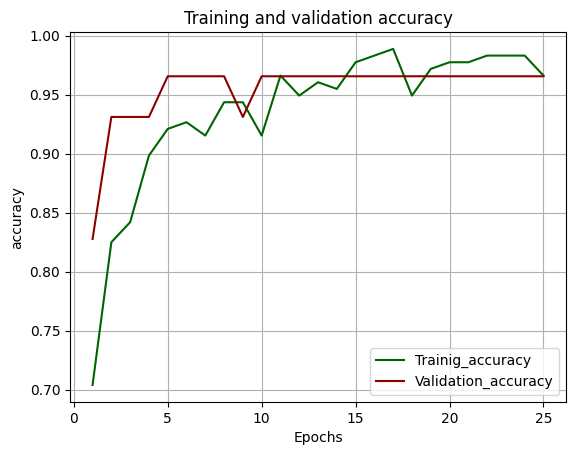

In [ ]:
loss = history.history['accuracy']
val_loss = history.history['val_accuracy']
epochs = range(1, len(loss)+ 1)
plt.plot(epochs, loss, 'darkgreen', label = 'Trainig_accuracy'),
plt.plot(epochs, val_loss, 'darkred', label = 'Validation_accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.grid()
